In [1]:
import os
import sys
import pandas
pandas.options.mode.chained_assignment = None  # default='warn'
from datetime import datetime, timedelta
import pytz
import shapely
from shapely import wkb, wkt
import geopandas
import duckdb
import pystac_client

sys.path.insert(1, os.path.abspath("../.."))
from qtree_index import nestedgrid, mortoncurve, qtree
from vectorstore import vectorstore

import matplotlib
matplotlib.use('Agg')
%matplotlib inline
import matplotlib.pyplot as plt

# Access credentials

In [2]:
import dotenv
dotenv.load_dotenv()

# S3 access key
access_key_id = os.getenv('access_key_id', '')
# S3 access secret
secret_access_key = os.getenv('secret_access_key', '')
# S3 access url
endpoint_url = os.getenv('endpoint_url', '')
# S3 bucket
bucket = os.getenv('bucket', '')

# STAC query for filtering assets

In [3]:
# Platform configuration
ISO_8601 = '%Y-%m-%dT%H:%M:%SZ'

# STAC service URL
STAC_URL="https://stac-fastapi-pgstac-nasageospatial-dev.cash.sl.cloud9.ibm.com"

# STAC catalogue
catalog = pystac_client.Client.open(STAC_URL)
collections = catalog.get_all_collections()
cl_id = [c.id for c in collections]
for c in cl_id:
    print(f"collection: {c}")

collection: esa-sentinel-2A-msil1c
collection: HLSS30
collection: global-weather-era5
collection: dev_ne_10m_admin_0_countries
collection: gedi-l2a
collection: atmospheric-era5
collection: test-gedi-l2a
collection: atmospheric-weather-era5
collection: ds335-sentinel1
collection: sentinel-1-grd
collection: dev_kaggle_wildfire
collection: ibm-eis-ga-1-esa-sentinel-2-l2a
collection: Radar
collection: Radar-10min
collection: tasmax-rcp85-land-cpm-uk-2.2km
collection: ibm-eis-ga-1-era5-pr-wdc
collection: HLSL30_version2
collection: vector-osm-power
collection: vector-osm-building
collection: vector-osm-poi
collection: vector-osm-road
collection: vector-osm-natural
collection: vector-osm-railway
collection: vector-osm-boundary
collection: vector-osm-landuse
collection: vector-osm-waterway
collection: dev-hsi-radar-10min


In [4]:
# Collection
collection_ids = [
    'vector-osm-power',
    'vector-osm-building',
    'vector-osm-poi',
    'vector-osm-road',
    'vector-osm-natural',
    'vector-osm-railway',
    'vector-osm-boundary',
    'vector-osm-landuse',
    'vector-osm-waterway',
]

In [5]:
collections={}
for collection_id in collection_ids:
    # Stac collection
    collections[collection_id] = catalog.get_collection(collection_id)
collections

{'vector-osm-power': <CollectionClient id=vector-osm-power>,
 'vector-osm-building': <CollectionClient id=vector-osm-building>,
 'vector-osm-poi': <CollectionClient id=vector-osm-poi>,
 'vector-osm-road': <CollectionClient id=vector-osm-road>,
 'vector-osm-natural': <CollectionClient id=vector-osm-natural>,
 'vector-osm-railway': <CollectionClient id=vector-osm-railway>,
 'vector-osm-boundary': <CollectionClient id=vector-osm-boundary>,
 'vector-osm-landuse': <CollectionClient id=vector-osm-landuse>,
 'vector-osm-waterway': <CollectionClient id=vector-osm-waterway>}

In [6]:
# Some parameters based on first collection
collection = collections[list(collections.keys())[0]]

# Get the names of the temporal and geometry columns from the collection
cube_dimensions = collection.extra_fields['cube:dimensions']
dt_col = [k for k in cube_dimensions if cube_dimensions[k]['type']=='temporal']
assert len(dt_col)==1 # Currently supporting just one temporal dimension
dt_col = dt_col[0]
geom_col = 'geometry' # Currently supporting just one geometry column called 'geometry'

In [7]:
# Query Parameters
query_polygon = shapely.box(-76.6, 42.3, -76.5, 42.4)
dt_start = datetime(1970, 1, 1, tzinfo=pytz.utc)
dt_end = datetime(2030, 1, 1, tzinfo=pytz.utc)-timedelta(seconds=1)

# Temporal query range
start = dt_start.strftime(ISO_8601)
end = dt_end.strftime(ISO_8601)
# STAC notation
time_range = f"{start}/{end}"

print(f"query bounds:   {query_polygon.bounds}")
print(f"time_range:     {time_range}")

query bounds:   (-76.6, 42.3, -76.5, 42.4)
time_range:     1970-01-01T00:00:00Z/2029-12-31T23:59:59Z


In [8]:
# Search the Stac catalog collection for matching items
limit=10000
search = catalog.search(collections=collection_ids, intersects=query_polygon, datetime=time_range, limit=limit)
items = search.item_collection().items
assert len(items)<limit

gdf_items = geopandas.GeoDataFrame.from_features(items)
hrefs = [item.assets['data'].href for item in items]
gdf_items['href'] = hrefs
print(f"items found: {len(items)}")

gdf_items.tail(2)

items found: 30


,geometry,proj:epsg,end_datetime,cube:variables,start_datetime,cube:dimensions,datetime,href
28,"POLYGON ((-60.64933 0.00006, -65.06403 0.00254...",4326,2024-05-19T23:37:05Z,"{'ref': {'type': 'data', 'unit': '', 'dimensio...",2006-10-01T15:33:19Z,"{'geometry': {'bbox': [-90.0, 6.09e-05, -46.78...",None,s3://fm-geospatial-cos-dev/vectorstore/osm_poi...
29,"POLYGON ((-77.30000 0.00000, -78.34807 0.00012...",4326,2024-05-19T23:52:03Z,"{'ref': {'type': 'data', 'unit': '', 'dimensio...",2006-07-05T22:24:34Z,"{'geometry': {'bbox': [-89.999437, 0.0, -49.49...",None,s3://fm-geospatial-cos-dev/vectorstore/osm_nat...


# Query remote data using DuckDB

## Speedup "within" queries using where_clause on quadkey index _root

In [9]:
def query_remote(endpoint_url, access_key_id, secret_access_key, query_polygon, hrefs):
    # get the grid information from href path
    grid_repr = hrefs[0].split('/grid=')[1].split('/')[0]
    grid = eval("nestedgrid." + grid_repr)
    print('grid: ', grid)
    
    max_depth = 0  # max_depth==0 cooresponds to the root key only
    qt = qtree.QTree(query_polygon, max_level=30, max_depth=max_depth, grid=grid)
    
    # Root of the query polygon
    root = qt.head.encode()
    print('root: ', root)
    
    # Increment the root key by one to get the upper bounds
    roots = [root]
    keys, levels = qt.morton.decode(roots)
    roots_max = qt.morton.encode(keys+1, levels)
    root_max = roots_max[0] # Since we started with just one [root]
    
    where_clause = ''
    where_clause += f"""(_root>='{root}')"""
    where_clause += f""" AND (_root<'{root_max}')"""
    where_clause += f""" AND ({dt_col}>='{dt_start}')"""
    where_clause += f""" AND ({dt_col}<='{dt_end}')"""
    
    # s3_endpoint e.g.: "s3.us-east.cloud-object-storage.appdomain.cloud"
    s3_endpoint = endpoint_url.split('https://')[1]#.split('s3.')[1]
    s3_region = 'us-east'
    
    # Setup
    db = duckdb.connect(":memory:")
    #db.execute("INSTALL aws; LOAD aws;")
    db.execute("INSTALL httpfs; LOAD httpfs;")
    db.execute("INSTALL spatial; LOAD spatial;")
    
    # Define Connection to Object Storage
    db.execute(f"SET s3_region='{s3_region}'")
    db.execute(f"SET s3_endpoint='{s3_endpoint}'")
    db.execute(f"SET s3_access_key_id='{access_key_id}'")
    db.execute(f"SET s3_secret_access_key='{secret_access_key}'")
    db.execute("SET s3_url_style='path'")
    #db.execute("SET s3_use_ssl=true")
    
    # Create a table view and pre-filter using WHERE so that we don't run into memory issues
    db.execute(f"CREATE VIEW tbl AS SELECT * FROM read_parquet({hrefs}) WHERE {where_clause}")
    cols = [t[0] for t in db.execute("describe tbl").fetchall()]
    #print('count', db.execute("SELECT count(*) FROM tbl").fetchall())
    
    # Create a derived table where the geometry column is a true geometry, not just a WKB.
    query = f"""
    CREATE OR REPLACE TABLE tbl2 AS
        SELECT *, ST_GEOMFROMWKB(geometry) as geom
        FROM tbl;
    """
    db.execute(query)
    cols2 = [t[0] for t in db.execute(f"""describe tbl2""").fetchall()]
    
    # Do the query
    json_string = shapely.to_geojson(query_polygon) # Upstate Ithaca
    #query = f"""select * from tbl2 where ST_INTERSECTS(geom, ST_GeomFromGeoJSON('{json_string}'))"""
    query = f"""select * from tbl2 where ST_WITHIN(geom, ST_GeomFromGeoJSON('{json_string}'))"""
    gdf = db.execute(query).fetchall()
    gdf = pandas.DataFrame(gdf, columns=cols2)
    gdf['geometry'] = gdf['geometry'].apply(lambda x: wkb.loads(x, hex=True))

    return geopandas.GeoDataFrame(gdf)

In [10]:
%%time
gdf = query_remote(endpoint_url, access_key_id, secret_access_key, query_polygon, hrefs)
# Drop duplicates coming from different osm collections
gdf = gdf.drop_duplicates().reset_index(drop=True)
gdf.tail(2)

grid:  World(4326)
root:  0q0302322110


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

CPU times: total: 33.7 s
Wall time: 1min 27s


,address,admin_level,aerialway,aeroway,amenity,barrier,boundary,building,craft,emergency,...,shop,sport,tourism,type,waterway,z_order,_root,grid,spatial_partition,geom
4115,None,None,None,None,None,None,None,None,None,None,...,None,None,information,None,None,NaN,0q03023221102102211122100121,World(4326),0q030232,b'\x00\x00\x18\x00\x00\x00\x00\x00\x00\x00\x00...
4116,None,None,None,None,restaurant,None,None,None,brewery,None,...,None,None,None,None,None,NaN,0q03023221102103032002223301,World(4326),0q030232,b'\x00\x00\x18\x00\x00\x00\x00\x00\x00\x00\x00...


In [11]:
gdf_road = gdf[gdf['highway'].notnull()]
gdf_building = gdf[gdf['building'].notnull()]
gdf_power = gdf[gdf['power'].notnull()]
gdf_railway = gdf[gdf['railway'].notnull()]
gdf_boundary = gdf[gdf['boundary'].notnull()]
gdf_landuse = gdf[gdf['landuse'].notnull()]
gdf_waterway = gdf[gdf['waterway'].notnull()]
gdf_natural = gdf[gdf[['natural', 'geological']].notnull().any(axis=1)]
gdf_poi = gdf[gdf[['amenity', 'shop', 'tourism', 'craft', 'emergency', 'historic', 'office', 'sport']].notnull().any(axis=1)]

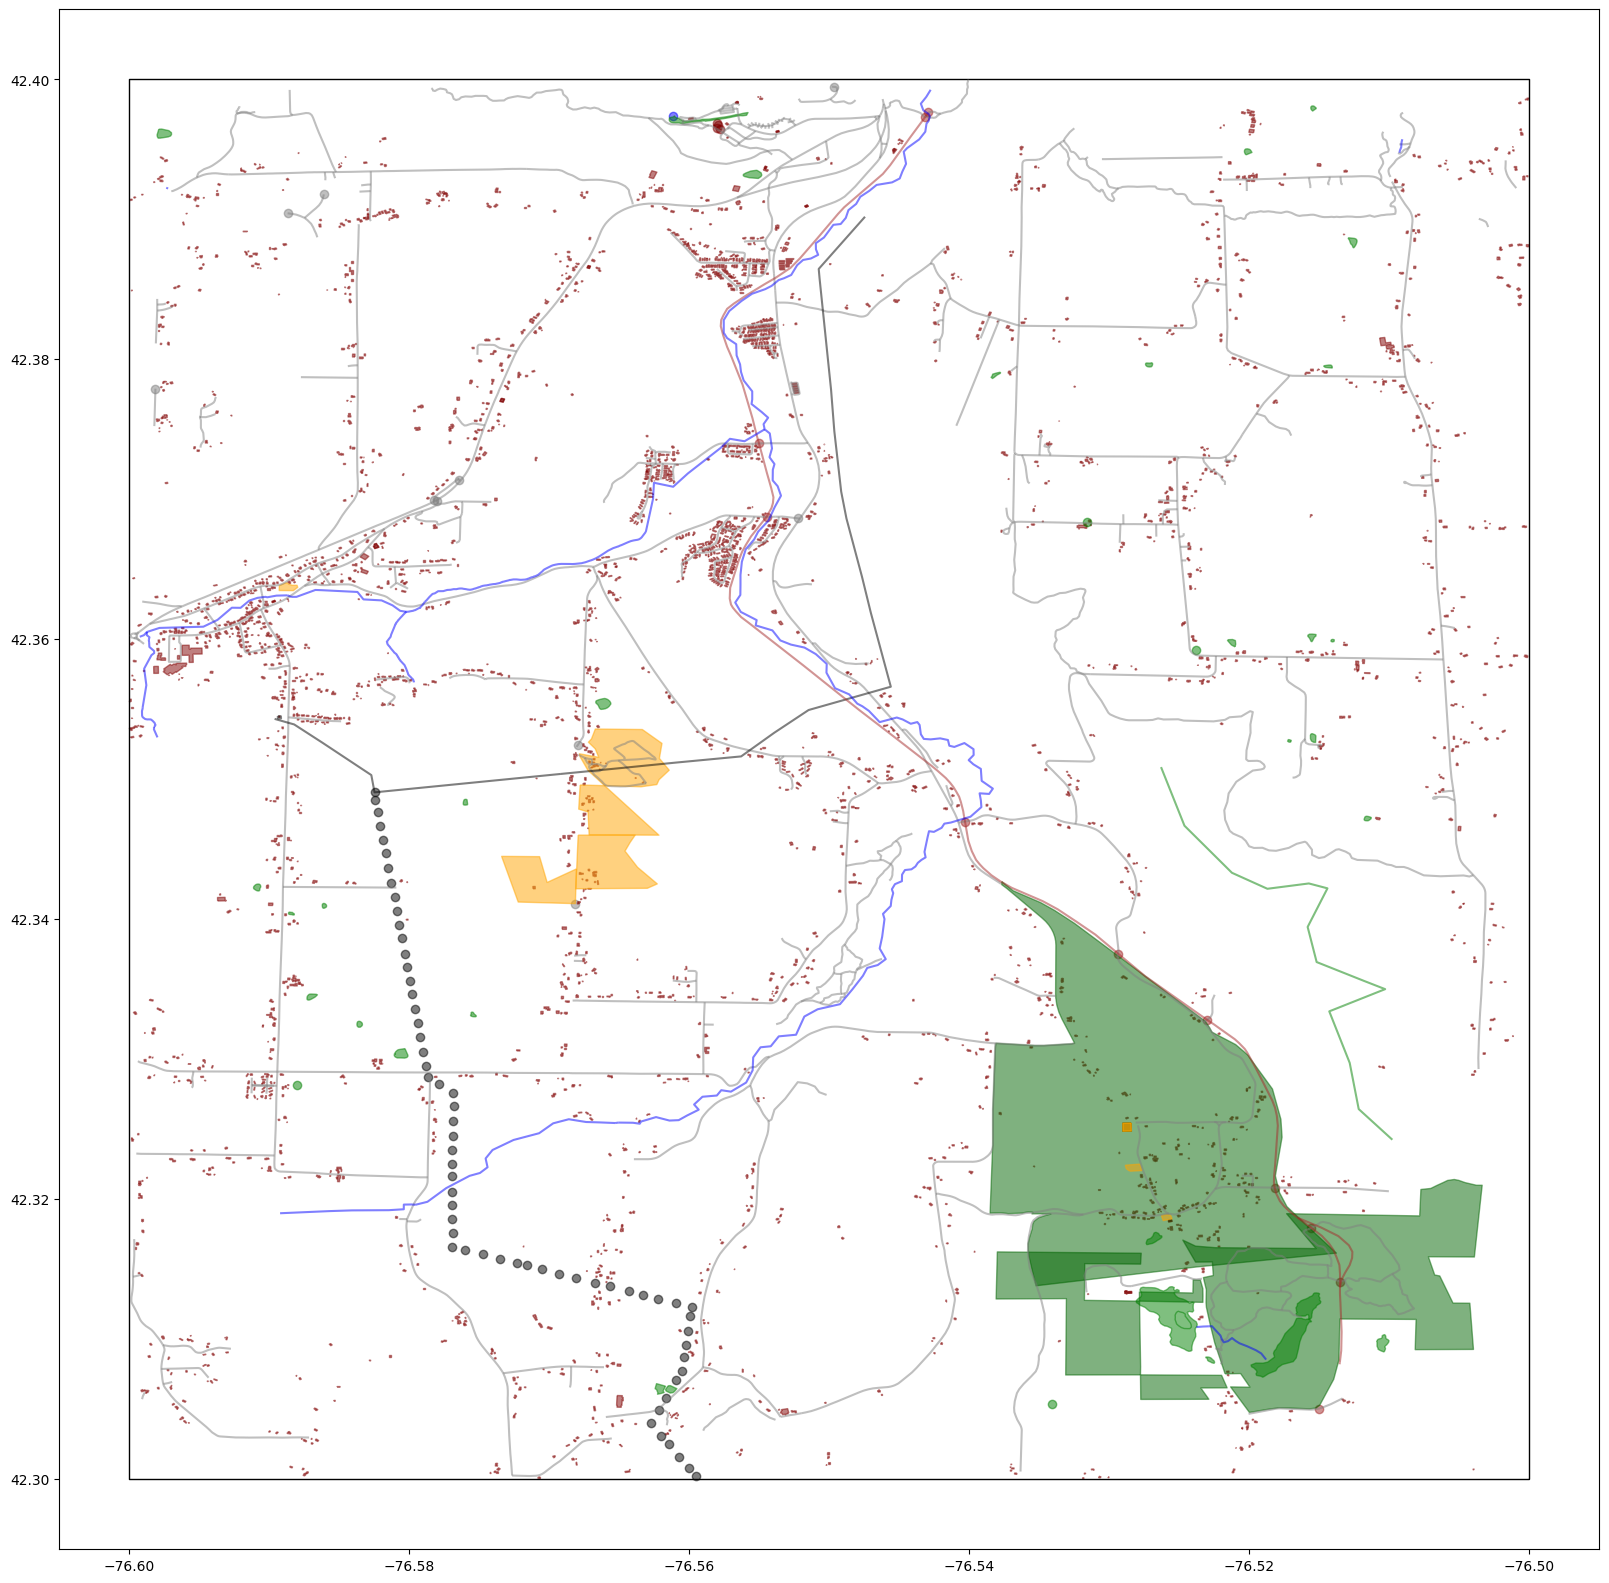

In [12]:
ax = gdf_road.plot(color='gray', edgecolor='gray', alpha=.5, figsize=(20,20))
gdf_building.plot(ax=ax, color='maroon', edgecolor='maroon', alpha=.5, figsize=(20,20))
gdf_power.plot(ax=ax, color='k', edgecolor='k', alpha=.5, figsize=(20,20))
gdf_railway.plot(ax=ax, color='brown', edgecolor='brown', alpha=.5, figsize=(20,20))
gdf_boundary.plot(ax=ax, color='darkgreen', edgecolor='darkgreen', alpha=.5, figsize=(20,20))
gdf_landuse.plot(ax=ax, color='orange', edgecolor='orange', alpha=.5, figsize=(20,20))
gdf_waterway.plot(ax=ax, color='blue', edgecolor='blue', alpha=.5, figsize=(20,20))
gdf_natural.plot(ax=ax, color='green', edgecolor='green', alpha=.5, figsize=(20,20))
geopandas.GeoDataFrame([{'geometry': query_polygon}]).plot(ax=ax, color='none', edgecolor='k')
plt.show()